# Dataset 2: CICIDS-2017 Exploration (Phase 11)

**Goal:** CICIDS-2017 is one of the most famous datasets in cybersecurity, but it is notoriously difficult to work with. 
Unlike NSL-KDD, it is massive and split across **8 different CSV files** based on the day of the week. Our first task is to professionally merge them together, check for corrupt data, and analyze the cyber attacks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

plt.style.use('ggplot')

### Step 1: Multi-File Loading (Subphase 11.1)
Instead of writing `pd.read_csv` 8 times, professional engineers use a library called `glob` to find all the files, and loop through them.
*Crucial trick:* We will extract the day of the week from the filename and add it as a new column! This allows us to track *when* the attacks happened later.

In [2]:
# 1. Find all 8 CSV files in the folder
file_paths = glob.glob("../data/raw/cicids-2017/*.csv")

dataframes = []
print("Loading files...")

for file in file_paths:
    # Load the CSV
    df_part = pd.read_csv(file)
    
    # Extract the filename (e.g., 'Monday-WorkingHours.pcap_ISCX.csv')
    filename = os.path.basename(file)
    # We extract just the day name (e.g., 'Monday') and add it as a new column!
    df_part['capture_day'] = filename.split('-')[0]
    
    dataframes.append(df_part)
    print(f"Loaded: {filename} ({len(df_part)} rows)")

# 2. Merge all the dataframes into one massive table
df = pd.concat(dataframes, ignore_index=True)
print(f"\nSUCCESS! Total rows loaded: {len(df):,}")

Loading files...


Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv (225745 rows)


Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv (286467 rows)


Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv (191033 rows)


Loaded: Monday-WorkingHours.pcap_ISCX.csv (529918 rows)


Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv (288602 rows)


Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv (170366 rows)


Loaded: Tuesday-WorkingHours.pcap_ISCX.csv (445909 rows)


Loaded: Wednesday-workingHours.pcap_ISCX.csv (692703 rows)



SUCCESS! Total rows loaded: 2,830,743


### Step 2: Fixing the Hidden Whitespace Bug
The creators of CICIDS-2017 accidentally left hidden spaces in their column names (e.g., `" Destination Port"` instead of `"Destination Port"`). 
This causes huge headaches for students. Let's fix it instantly by stripping all whitespace.

In [3]:
# Strip spaces from the beginning and end of every column name
df.columns = df.columns.str.strip()

print("Cleaned Column Names (First 10):")
print(list(df.columns)[:10])

Cleaned Column Names (First 10):
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


### Step 3: Data Quality Check (Subphase 11.3)
Real-world data is dirty. In network traffic, sometimes a packet calculation results in **Infinity (Inf)** or **Not a Number (NaN)**. 
If we don't find these now, they will violently crash our AI during the training phase.

In [4]:
# 1. Replace mathematical Infinity with NaN so pandas can count it easily
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Count all the missing (NaN) values in every column
missing_data = df.isnull().sum()

# 3. Show only columns that actually have broken data
broken_columns = missing_data[missing_data > 0]
print("Columns with Corrupted/Missing Data:")
print(broken_columns)

Columns with Corrupted/Missing Data:
Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64


### Step 4: Class Imbalance Analysis (Subphase 11.2)
What kind of cyber attacks are we dealing with? Let's count the `Label` column.
*Note: Because 'BENIGN' (normal traffic) is so unbelievably massive, we have to plot it on a **Logarithmic Scale**, otherwise the attack bars would be microscopically small!*

Label
BENIGN              2273097
DoS Hulk             231073
PortScan             158930
DDoS                 128027
DoS GoldenEye         10293
FTP-Patator            7938
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Bot                    1966
Name: count, dtype: int64


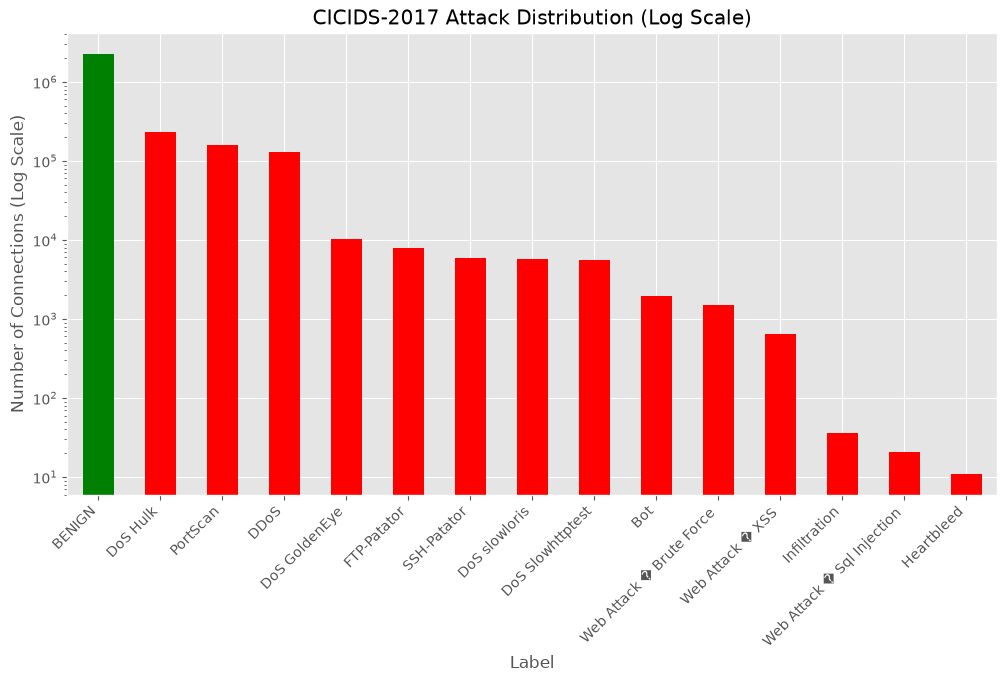

In [5]:
# 1. Count the attacks
label_counts = df['Label'].value_counts()
print(label_counts.head(10))

# 2. Plot them on a Log Scale graph
plt.figure(figsize=(12, 6))
colors = ['green' if label == 'BENIGN' else 'red' for label in label_counts.index]

label_counts.plot(kind='bar', color=colors)
plt.yscale('log')  # This makes the Y-axis multiply by 10 instead of adding

plt.title("CICIDS-2017 Attack Distribution (Log Scale)")
plt.ylabel("Number of Connections (Log Scale)")
plt.xticks(rotation=45, ha='right')
plt.show()

---
### Step 5: Temporal Pattern Analysis (Subphase 11.4)
Because we extracted the `capture_day` from the filenames in Step 1, we can now analyze *when* attacks happen.
Let's look at a stacked bar chart of the cyber attacks across the days of the week. 
*(We will exclude BENIGN traffic from this chart so we can clearly see the attack patterns).* 

Notice how different attacks are grouped on specific days (e.g., Web Attacks on Thursday, DDoS on Friday). This is a massive hint that this dataset has severe **temporal bias**!

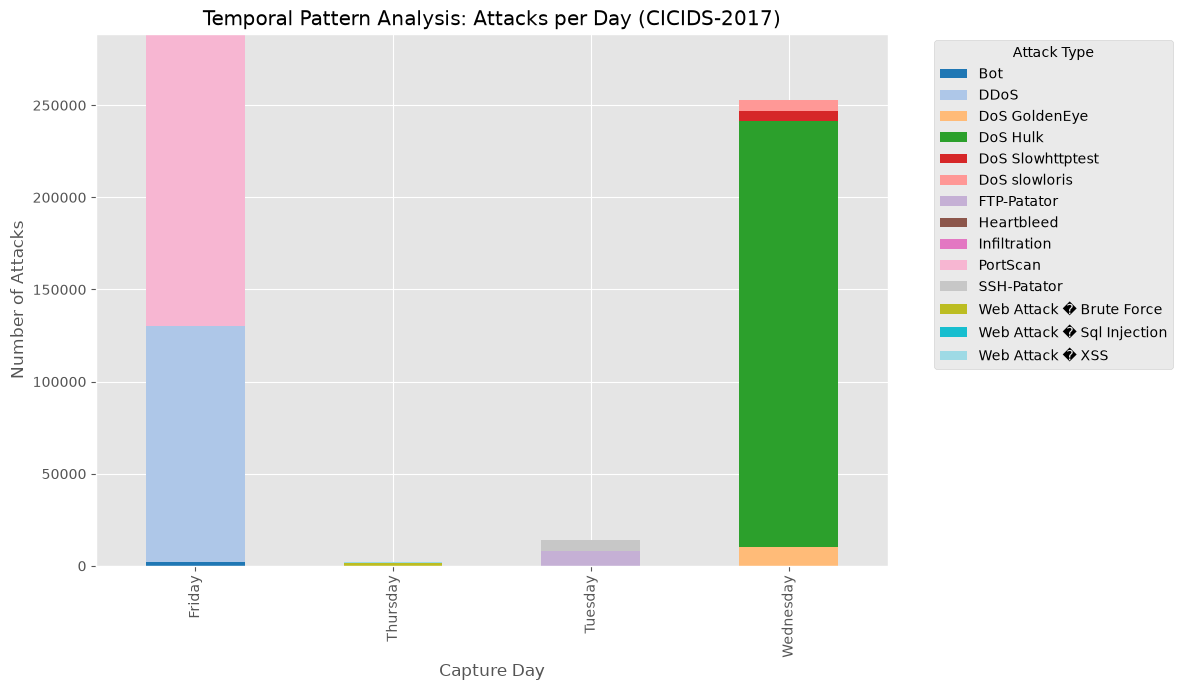

In [6]:
# 1. Filter out normal traffic so the chart isn't squashed
attacks_only = df[df['Label'] != 'BENIGN']

# 2. Group the data by Day and Attack Type, then count them
temporal_counts = attacks_only.groupby(['capture_day', 'Label']).size().unstack(fill_value=0)

# 3. Plot a stacked bar chart
temporal_counts.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title("Temporal Pattern Analysis: Attacks per Day (CICIDS-2017)")
plt.xlabel("Capture Day")
plt.ylabel("Number of Attacks")

# Move the legend outside the chart so it doesn't block the bars
plt.legend(title="Attack Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
### Step 5: EDA Findings & Conclusion
Here is the official **Action Plan** for CICIDS-2017 that we will use in the Data Cleaning phase:

1. **Dirty Columns:** We discovered that `Flow Bytes/s` and `Flow Packets/s` contain NaN and Infinity values. 
   * **Action:** During the cleaning phase, we will write code to mathematically replace these broken values with the 'Median' value of the dataset, otherwise the AI will crash.
2. **Extreme Imbalance:** Normal `BENIGN` traffic dominates the dataset at an extreme scale (over 2 million rows!).
   * **Action:** We absolutely must use **Class Weights** or **SMOTE** downsampling during training, otherwise the AI will just guess 'BENIGN' every single time to get a 90% accuracy score without learning any cyber attacks.
3. **Temporal Tracking:** By saving the `capture_day`, we now have the power to test our AI's robustness across time (e.g., train on Monday, test on Friday).

---
### Step 6: Feature Multicollinearity (Subphase 11.5)
CICIDS-2017 has 78 different features. Do we really need all 78 to detect an attack? 
Probably not. Many features are **Multicollinear** (meaning they are mathematical duplicates of each other). For example, if we know the total forward packets, the total forward bytes is often highly correlated.

Let's write a script to automatically find features that are >95% correlated so we can delete them in the data cleaning phase!

In [7]:
# 1. Take a random sample so our computer doesn't crash doing a 78x78 matrix on 2.8M rows
print("Sampling 100,000 rows for correlation math...")
df_sample = df.sample(n=100000, random_state=42).select_dtypes(include=['number'])

# 2. Calculate the Pearson Correlation matrix (absolute values)
corr_matrix = df_sample.corr().abs()

# 3. Extract the upper triangle so we don't count pairs twice (A-B and B-A)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Find all features that have a correlation > 0.95 with another feature
redundant_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

print(f"\nSUCCESS! Found {len(redundant_features)} redundant features.")
print("\nHere are some of the 'Selection Candidates' we can safely delete later:")
for feature in redundant_features[:10]:
    print(f"- {feature}")

Sampling 100,000 rows for correlation math...



SUCCESS! Found 27 redundant features.

Here are some of the 'Selection Candidates' we can safely delete later:
- Total Backward Packets
- Total Length of Bwd Packets
- Fwd Packet Length Std
- Bwd Packet Length Mean
- Bwd Packet Length Std
- Fwd IAT Total
- Fwd IAT Max
- Fwd Header Length
- Bwd Header Length
- Fwd Packets/s
